# Exploring the Cambodian Bombing Data

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio.mask import mask
from rasterio.plot import show
import numpy as np
import matplotlib.colors as colors


%matplotlib inline
%config InlineBackend.figure_format = "retina"

In [11]:
CambodiaBombingGDF = gpd.read_file('../data/CambodiaBombing.geojson')

There are no missing coordinates, and this is a Cambodia-only dataset from a seemingly reputable organization, so maybe we can just proceed with plotting without too much cleaning. 

In [6]:
CambodiaBombingGDF.head()

,OBJECTID,AREA,PERIMETER,ORDNANCE_K,ORDNANCE_1,DATE,LAT,LON,NUM_ACRFT,AIRCRAFT,LOAD_QTY,LOAD_LBS,ORDNANCE,ORD_CLASS,CATEGORY,TARGET,BDA,LATLONKEY,COUNT_,geometry
0,1.0,None,0.0,1.0,928423.0,1970-04-05,14.68601,107.53532,2.0,F-100 D,6.0,50.0,20MM M39 (In Hundreds),M-39,Ammunition,Area/Depot,ONTGT/NO BDA,266088.0,1,POINT (773456.625 1624806.5)
1,2.0,None,0.0,2.0,928424.0,1970-04-05,14.68601,107.53532,2.0,F-100 D,8.0,799.0,750 LB General Purpose Bomb,750LB GP M-117,General_Purpose,Area/Depot,ONTGT/NO BDA,266088.0,1,POINT (773456.625 1624806.5)
2,3.0,None,0.0,3.0,928425.0,1970-04-05,14.68601,107.53532,2.0,F-100 D,8.0,799.0,750 LB General Purpose Bomb,750LB GP M-117,General_Purpose,Command Post,ONTGT/NO BDA,266088.0,1,POINT (773456.625 1624806.5)
3,4.0,None,0.0,4.0,1265223.0,1970-04-05,14.68484,107.53496,2.0,F100,8.0,32832.0,M117 GP Bomb 18 Fuse,750LB GP/M-117,General_Purpose,Command Post Area,Target,266006.0,1,POINT (773419.437 1624676.5)
4,5.0,None,0.0,5.0,1265222.0,1970-04-05,14.68484,107.53496,2.0,F4,4.0,46032.0,MK84 GP Bomb,2000LB MK-84,General_Purpose,None,None,266006.0,1,POINT (773419.437 1624676.5)


In [48]:
CambodiaBombingGDF = CambodiaBombingGDF[['DATE','LAT', 'LON', 'LATLONKEY', 'LOAD_QTY', 'LOAD_LBS', 'CATEGORY','geometry']]

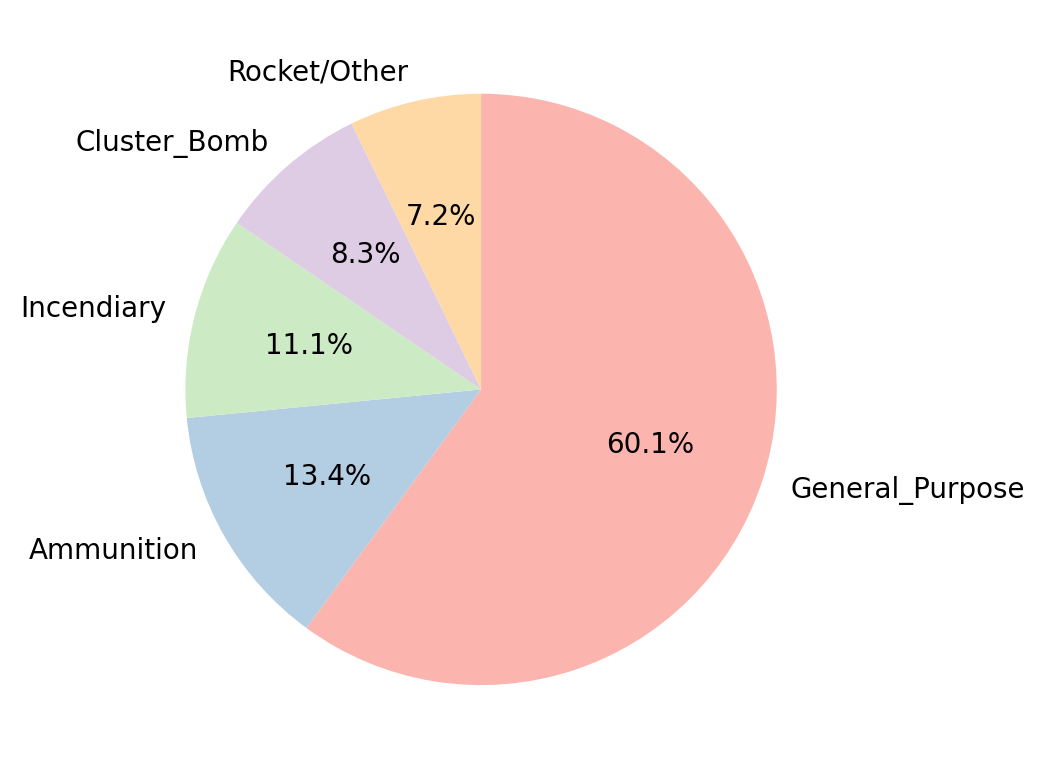

In [47]:
# Creating a pie chart to visualize the kinds of munitions used 
percentages = CambodiaBombingGDF['CATEGORY'].value_counts(normalize=True)

other = percentages[percentages < 0.05].index

CambodiaBombingGDF['Grouped'] = CambodiaBombingGDF['CATEGORY'].replace(other, 'Rocket/Other')

cmap = plt.get_cmap('Pastel1')
slice_colors = cmap(np.arange(len(percentages)))

CambodiaBombingGDF['Grouped'].value_counts().plot.pie(
    autopct='%1.1f%%', 
    startangle=90, 
    colors=slice_colors,
    counterclock=False
)
plt.ylabel('')  
plt.savefig('../figures/weaponCategoryPieChart.png')
plt.show()

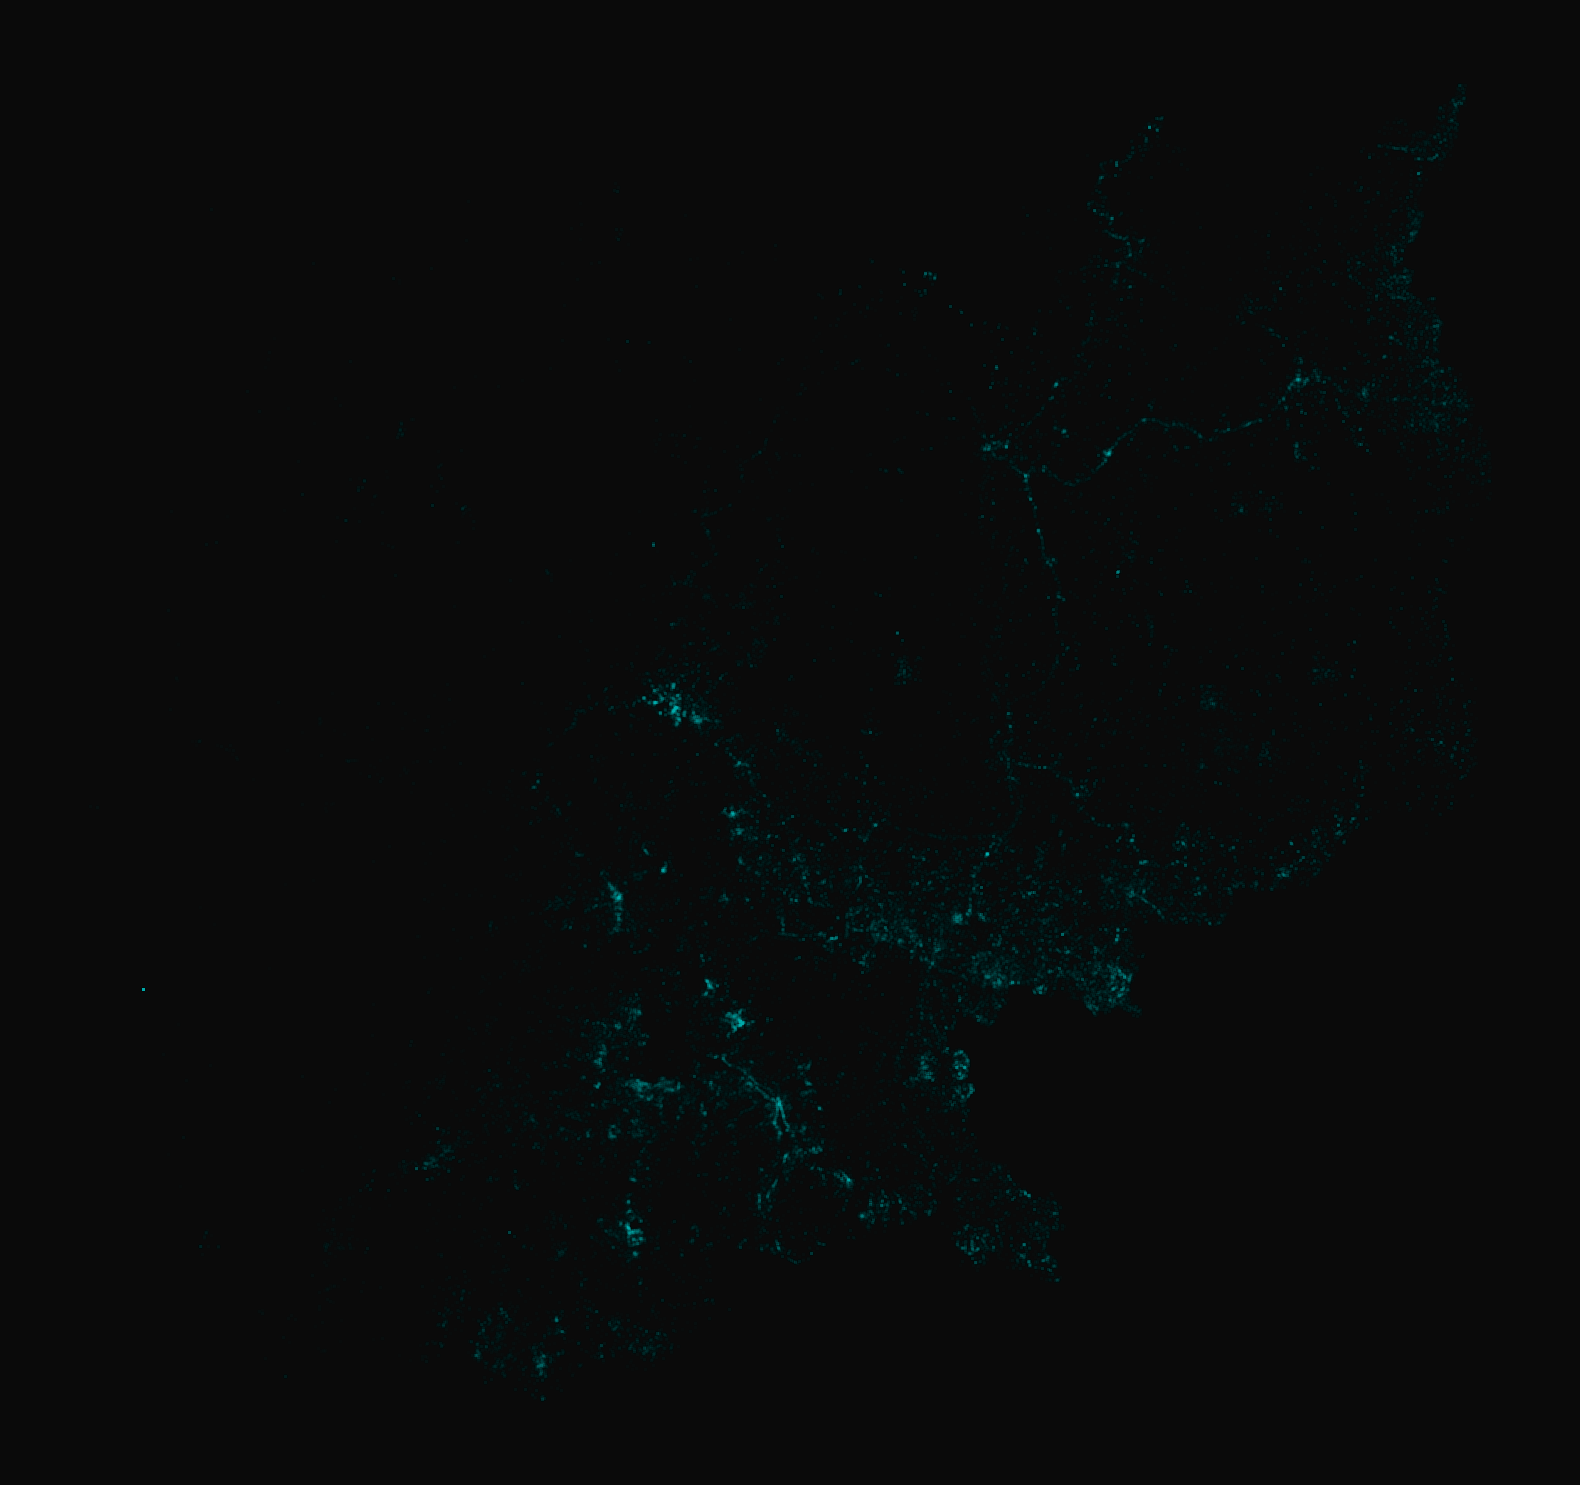

In [52]:
# Initializing canvas
fig, ax = plt.subplots(figsize=(8, 16), facecolor='#0a0a0a')
ax.set_facecolor('#0a0a0a')

CambodiaBombingGDF.plot(
    ax=ax, color='#00ffff', markersize=2.0, alpha=0.01, linewidth=0
)

ax.axis('off')
plt.tight_layout()